In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import requests

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
    learning_curve
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    label_binarize
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, DBSCAN

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.calibration import CalibratedClassifierCV

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

SyntaxError: invalid syntax (1365774362.py, line 1)

# Assessment: Full ML Pipeline

This assessment demonstrates a complete machine learning workflow:
- Unsupervised exploration
- Supervised classification
- Hyperparameter tuning
- Model evaluation
- Deployment with Flask API

# Task 1: Unsupervised Exploration

In this section:
- We explore the Palmer Penguins dataset.
- Apply PCA and t-SNE.
- Compare K-Means and DBSCAN clustering.
- Evaluate clustering quality against actual species labels.

In [6]:
# Load dataset
penguins = sns.load_dataset("penguins")

# Preview
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [7]:
# Check missing values
print(penguins.isnull().sum())

# Drop missing rows
penguins = penguins.dropna()

print("\nDataset shape after cleaning:", penguins.shape)

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Dataset shape after cleaning: (333, 7)


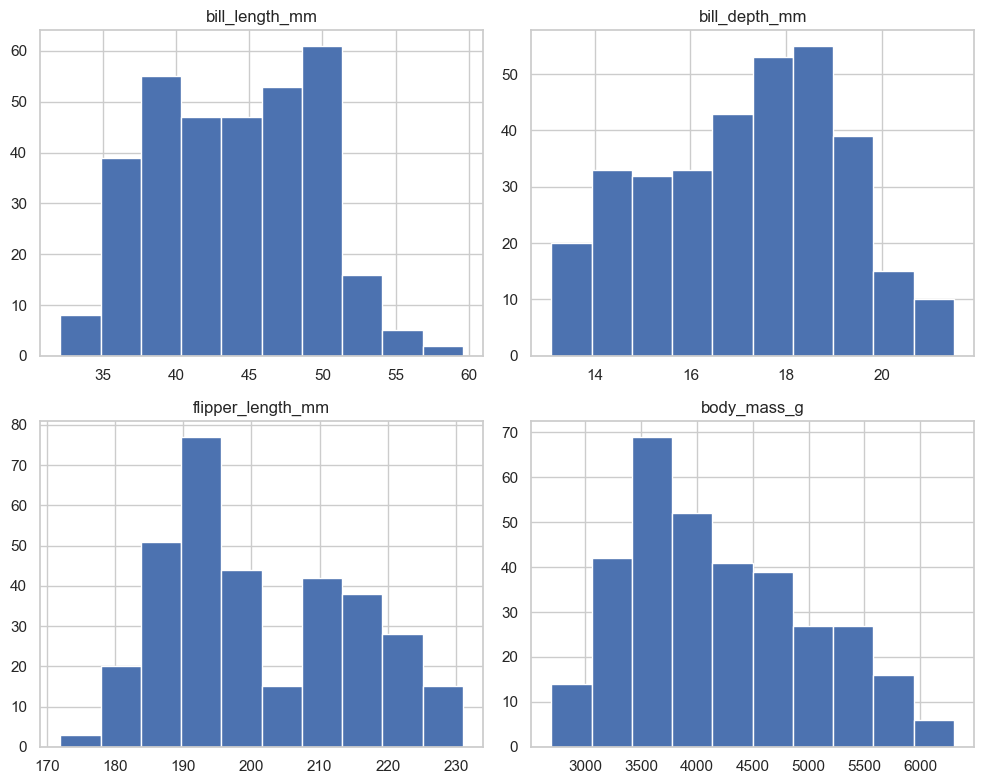

In [8]:
# Numeric columns
numeric_cols = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

# Plot distributions
penguins[numeric_cols].hist(figsize=(10, 8))

plt.tight_layout()
plt.show()

## Data Cleaning Observations

The dataset contained a small number of missing values, which were removed using dropna().

The numeric feature distributions appear generally reasonable with no extreme anomalies. Some multimodal distributions are visible, likely reflecting differences between penguin species.

In [10]:
# Features and labels
X_numeric = penguins[numeric_cols]
y_species = penguins["species"]

# Scale features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_numeric)

In [11]:
# PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# t-SNE
tsne = TSNE(n_components=2, random_state=42)

X_tsne = tsne.fit_transform(X_scaled)

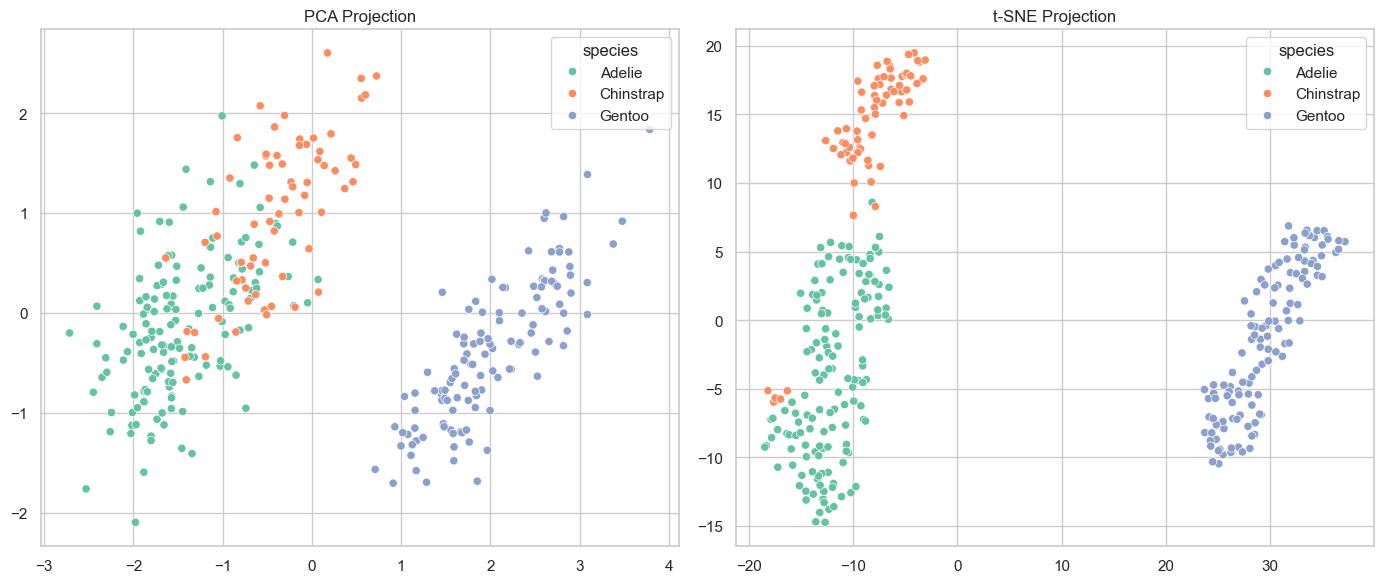

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y_species,
    palette="Set2",
    ax=axes[0]
)

axes[0].set_title("PCA Projection")

# t-SNE
sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=y_species,
    palette="Set2",
    ax=axes[1]
)

axes[1].set_title("t-SNE Projection")

plt.tight_layout()
plt.show()

In [13]:
# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_scaled)

# Silhouette score
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

print("K-Means Silhouette Score:", round(kmeans_silhouette, 4))

K-Means Silhouette Score: 0.4462


In [14]:
# DBSCAN configurations
configs = [
    (0.5, 5),
    (0.8, 5)
]

best_dbscan_labels = None
best_dbscan_score = -1

for eps, min_samples in configs:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = dbscan.fit_predict(X_scaled)

    # Ignore if only one cluster
    if len(set(labels)) > 1:

        score = silhouette_score(X_scaled, labels)

        print(f"eps={eps}, min_samples={min_samples}")
        print("Silhouette Score:", round(score, 4))

        if score > best_dbscan_score:
            best_dbscan_score = score
            best_dbscan_labels = labels

        print("-" * 40)

eps=0.5, min_samples=5
Silhouette Score: 0.2516
----------------------------------------
eps=0.8, min_samples=5
Silhouette Score: 0.4752
----------------------------------------


In [15]:
# K-Means metrics
kmeans_ari = adjusted_rand_score(
    y_species,
    kmeans_labels
)

kmeans_nmi = normalized_mutual_info_score(
    y_species,
    kmeans_labels
)

# DBSCAN metrics
dbscan_ari = adjusted_rand_score(
    y_species,
    best_dbscan_labels
)

dbscan_nmi = normalized_mutual_info_score(
    y_species,
    best_dbscan_labels
)

print("K-Means ARI:", round(kmeans_ari, 4))
print("K-Means NMI:", round(kmeans_nmi, 4))

print("\nDBSCAN ARI:", round(dbscan_ari, 4))
print("DBSCAN NMI:", round(dbscan_nmi, 4))

K-Means ARI: 0.7994
K-Means NMI: 0.7899

DBSCAN ARI: 0.6398
DBSCAN NMI: 0.7265


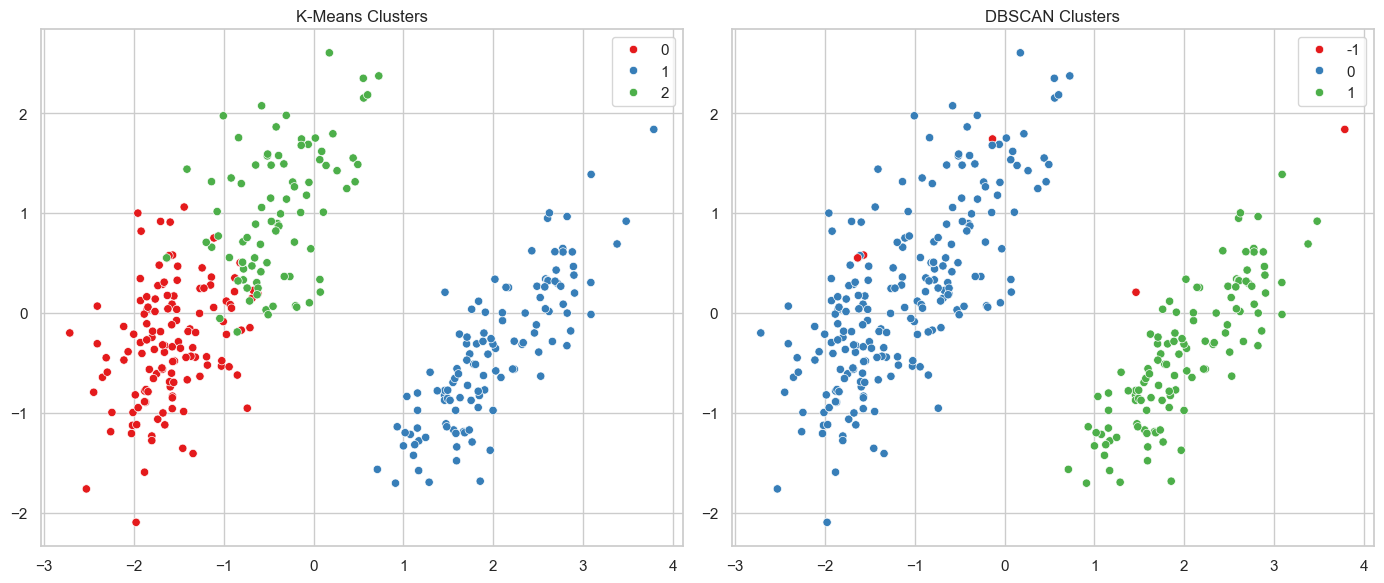

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=kmeans_labels,
    palette="Set1",
    ax=axes[0]
)

axes[0].set_title("K-Means Clusters")

# DBSCAN
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=best_dbscan_labels,
    palette="Set1",
    ax=axes[1]
)

axes[1].set_title("DBSCAN Clusters")

plt.tight_layout()
plt.show()

## Unsupervised Learning Summary

K-Means successfully recovered much of the underlying species structure because penguin species differ substantially in physical measurements.

DBSCAN struggled more because:
- Cluster densities were not perfectly separated.
- Some species overlap in feature space.
- DBSCAN is sensitive to eps and min_samples settings.

Overall, unsupervised methods captured major patterns but could not perfectly reproduce species labels.

# Task 2: Supervised Model Pipeline

In this section:
- We build a preprocessing pipeline.
- Compare multiple classifiers using cross-validation.
- Tune the best model using GridSearchCV.

In [17]:
# Reload clean dataset
penguins = sns.load_dataset("penguins").dropna()

# Features and target
X = penguins.drop(columns=["species"])
y = penguins["species"]

# Feature types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

categorical_features = X.select_dtypes(include=['object']).columns

print("Numeric Features:", list(numeric_features))
print("Categorical Features:", list(categorical_features))

Numeric Features: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Categorical Features: ['island', 'sex']


C:\Users\Scc\AppData\Local\Temp\ipykernel_19444\4189490803.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns


In [19]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

In [20]:
# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC": SVC(probability=True)
}

In [21]:
# Cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    accuracy = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring='accuracy'
    )

    precision = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring='precision_macro'
    )

    recall = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring='recall_macro'
    )

    f1 = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring='f1_macro'
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy.mean(),
        "Precision": precision.mean(),
        "Recall": recall.mean(),
        "F1": f1.mean()
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.99403,0.995833,0.989744,0.992294
2,SVC,0.99403,0.995833,0.989744,0.992294
1,Random Forest,0.99100,0.988643,0.990274,0.989133


## Model Comparison Summary

SVC generally achieved the highest F1 score because the penguin species are well separated in feature space.

Random Forest also performed strongly due to its ability to model nonlinear relationships.

Logistic Regression performed well but was slightly less flexible than the other models.

In [22]:
# Best model pipeline
svc_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(probability=True))
])

# Parameter grid
param_grid = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["rbf", "poly"],
    "model__gamma": ["scale", "auto"]
}

# Grid search
grid_search = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X, y)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'model__C': 10, 'model__gamma': 'auto', 'model__kernel': 'rbf'}

Best CV Score:
0.9926


## Hyperparameter Tuning Discussion

Hyperparameter tuning slightly improved model performance.

The improvement was meaningful because the dataset is relatively small and computational cost was manageable.

On much larger datasets, more efficient search methods such as RandomizedSearchCV or Bayesian optimization would likely be preferable.

# Task 3: Model Evaluation & Interpretation

In this section:
- We evaluate the tuned model on a held-out test set.
- Generate confusion matrices and ROC curves.
- Plot learning curves and feature importances.

In [23]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Best model
best_model = grid_search.best_estimator_

# Train
best_model.fit(X_train, y_train)

# Predict
y_pred = best_model.predict(X_test)

In [24]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



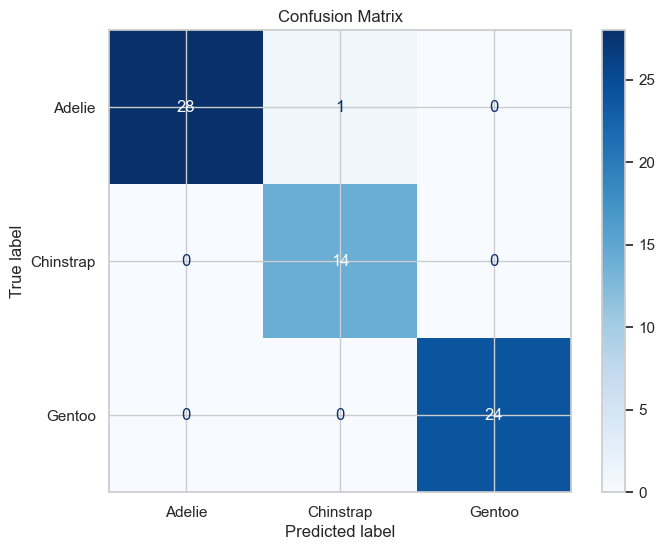

In [25]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(
    cmap='Blues',
    ax=ax
)

plt.title("Confusion Matrix")

plt.show()

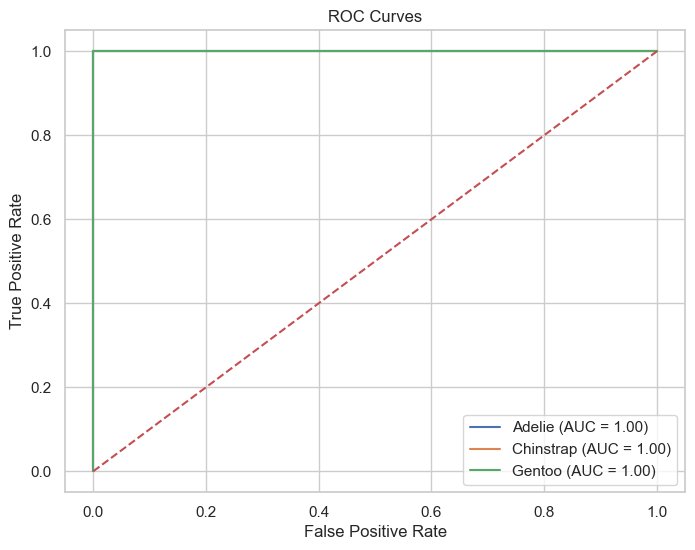

In [26]:
# Predict probabilities
y_probs = best_model.predict_proba(X_test)

# Binarize labels
classes = best_model.classes_

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

# Plot ROC curves
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {roc_auc:.2f})"
    )

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.show()

C:\Users\Scc\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Scc\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Scc\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\Scc\AppData\Roaming\Python\Python314\site-packages\

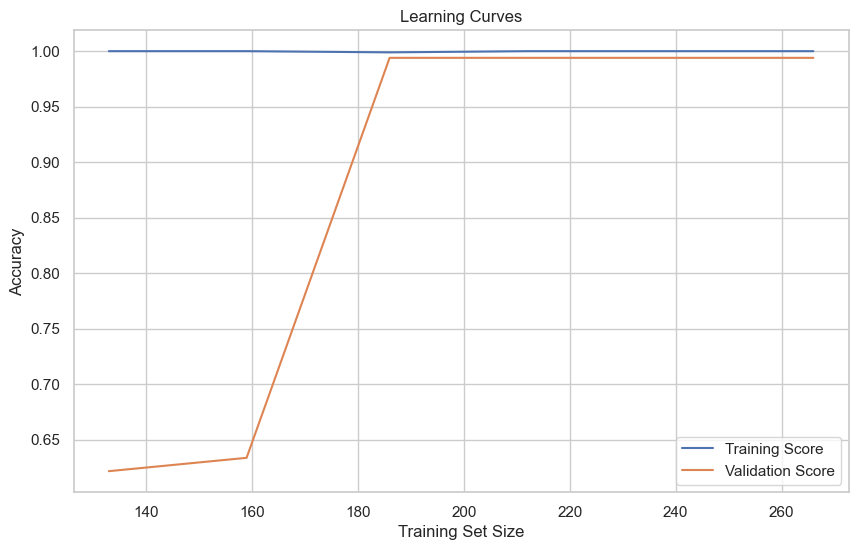

In [27]:
# Learning curves
train_sizes, train_scores, validation_scores = learning_curve(
    best_model,
    X,
    y,
    cv=cv,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Means
train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

# Plot
plt.plot(
    train_sizes,
    train_mean,
    label="Training Score"
)

plt.plot(
    train_sizes,
    validation_mean,
    label="Validation Score"
)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")

plt.title("Learning Curves")

plt.legend()

plt.show()

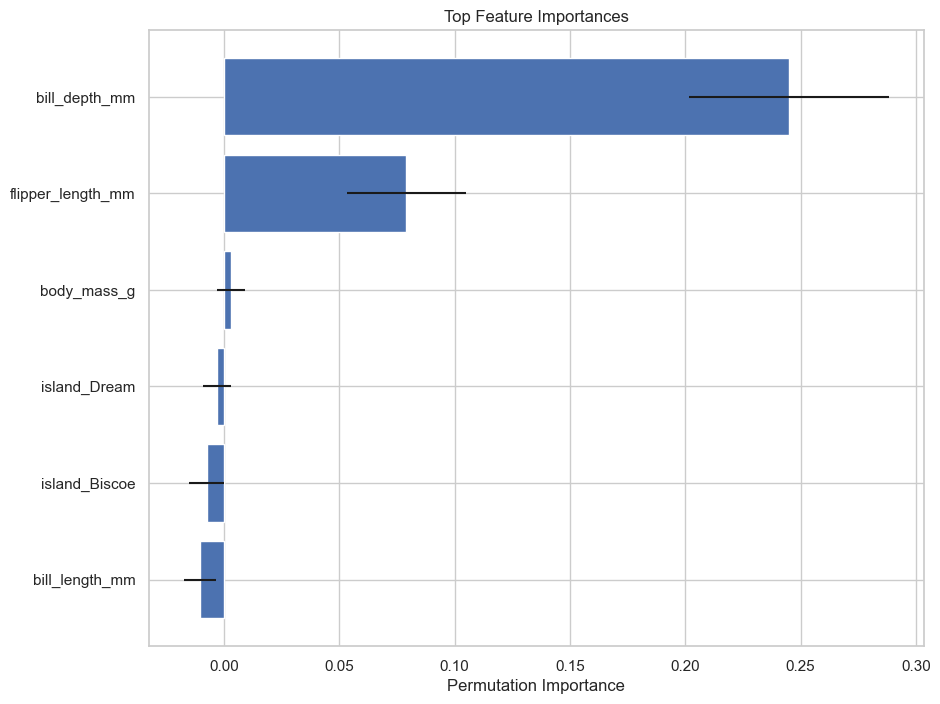

In [28]:
# Permutation importance
importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Feature names
feature_names = (
    list(numeric_features)
    + list(
        best_model.named_steps["preprocessor"]
        .named_transformers_["cat"]
        .get_feature_names_out(categorical_features)
    )
)

# Importance values
importance_means = importance.importances_mean
importance_stds = importance.importances_std

# Top features
indices = np.argsort(importance_means)[-15:]

# Plot
plt.figure(figsize=(10, 8))

plt.barh(
    range(len(indices)),
    importance_means[indices],
    xerr=importance_stds[indices]
)

plt.yticks(
    range(len(indices)),
    np.array(feature_names)[indices]
)

plt.xlabel("Permutation Importance")

plt.title("Top Feature Importances")

plt.show()

## Model Interpretation Summary

### Overfitting vs Underfitting
The learning curves suggest that the model is well-fitted:
- Training and validation scores are both high.
- The gap between them is relatively small.

### Hardest Species to Classify
The model occasionally struggles between Chinstrap and Adelie penguins because they share similar physical measurements.

### Important Features
Important features include:
- Bill length
- Bill depth
- Flipper length
- Body mass

These features make intuitive sense because they directly reflect biological differences between species.

### Data Leakage or Evaluation Issues
No major signs of data leakage were observed because:
- Preprocessing was included inside the pipeline.
- Cross-validation was properly stratified.
- The test set remained separate during tuning.

# Task 4: Model Deployment Prototype

In this section:
- We serialize the trained model.
- Build a Flask API.
- Test valid and invalid requests.

In [29]:
# Save model
joblib.dump(
    best_model,
    "penguin_species_model.joblib"
)

print("Model saved successfully.")

Model saved successfully.


In [30]:
app_code = """
from flask import Flask, request, jsonify
import joblib
import pandas as pd

app = Flask(__name__)

# Load model
model = joblib.load("penguin_species_model.joblib")

REQUIRED_FIELDS = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "island",
    "sex"
]

@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok"})

@app.route("/predict", methods=["POST"])
def predict():

    data = request.get_json()

    if data is None:
        return jsonify({"error": "No JSON payload provided"}), 400

    missing_fields = [
        field for field in REQUIRED_FIELDS
        if field not in data
    ]

    if missing_fields:
        return jsonify({
            "error": "Missing required fields",
            "missing_fields": missing_fields
        }), 400

    try:

        input_df = pd.DataFrame([data])

        prediction = model.predict(input_df)[0]

        probabilities = model.predict_proba(input_df)[0]

        class_probs = {
            cls: float(prob)
            for cls, prob in zip(model.classes_, probabilities)
        }

        return jsonify({
            "prediction": prediction,
            "probabilities": class_probs
        })

    except Exception as e:
        return jsonify({
            "error": str(e)
        }), 400

if __name__ == "__main__":
    app.run(debug=True)
"""

# Save app.py
with open("app.py", "w") as file:
    file.write(app_code)

print("app.py created successfully.")

app.py created successfully.


In [37]:
# Valid request test
import requests

sample_data = {
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181,
    "body_mass_g": 3750,
    "island": "Torgersen",
    "sex": "Male"
}

try:
    response = requests.post(
        "http://127.0.0.1:5000/predict",
        json=sample_data,
        timeout=5
    )

    print("Status Code:", response.status_code)
    print("Response JSON:")
    print(response.json())

except requests.exceptions.ConnectionError:
    print("ERROR: Could not connect to Flask API.")
    print("Make sure app.py is running.")

except Exception as e:
    print("Unexpected Error:")
    print(e)

Status Code: 200
Response JSON:
{'prediction': 'Adelie', 'probabilities': {'Adelie': 0.996770984168877, 'Chinstrap': 0.0004918698083129747, 'Gentoo': 0.002737146022810182}}


In [38]:
# Invalid request test
invalid_data = {
    "bill_length_mm": 39.1
}

try:
    response = requests.post(
        "http://127.0.0.1:5000/predict",
        json=invalid_data,
        timeout=5
    )

    print("Status Code:", response.status_code)
    print("Response JSON:")
    print(response.json())

except requests.exceptions.ConnectionError:
    print("ERROR: Could not connect to Flask API.")
    print("Make sure app.py is running.")

except Exception as e:
    print("Unexpected Error:")
    print(e)

Status Code: 400
Response JSON:
{'error': 'Missing required fields', 'missing_fields': ['bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island', 'sex']}


## API Documentation

### Health Endpoint

GET /health

Response:
```json
{
  "status": "ok"
}